# Assignment 1 



Put this notebook in the same folder as:

- `support.py`
- `dataset_a1.txt`


In [1]:
import random

import time

import numpy as np
import matplotlib.pyplot as plt

from deap import base, creator, tools, algorithms

import support


## GA parameters

These are the initial parameter values for Task 1. 

In [2]:
POPULATION_SIZE = 80
N_GENERATIONS = 45
CROSSOVER_PROBABILITY = 0.8
MUTATION_PROBABILITY = 0.2
TOURNAMENT_SIZE = 3
PER_GENE_MUTATION_PROBABILITY = 0.05

RANDOM_SEED = 42

## Individual representation

A candidate Petri net is represented as a linearized matrix.

There are 12 transitions. Each transition has two numbers: start place and end place. Therefore, one individual has 12 * 2 = 24 integer values. Each integer is a place number from 0 to 8.

In [3]:
INDIVIDUAL_LENGTH = support.NR_TRANSITIONS * 2

LOWER_BOUND = 0
UPPER_BOUND = support.NR_PLACES - 1

print("Individual length:", INDIVIDUAL_LENGTH)
print("Allowed place values:", LOWER_BOUND, "to", UPPER_BOUND)

Individual length: 24
Allowed place values: 0 to 8


## DEAP setup

In [6]:
if "FitnessMax_Task1" not in creator.__dict__:
    creator.create("FitnessMax_Task1", base.Fitness, weights=(1.0,))

if "Individual_Task1" not in creator.__dict__:
    creator.create("Individual_Task1", list, fitness=creator.FitnessMax_Task1)

toolbox = base.Toolbox()

# One gene is one place number from 0 to 8.
toolbox.register("attr_place", random.randint, LOWER_BOUND, UPPER_BOUND)

# One individual is a list of 24 place numbers.
toolbox.register(
    "individual",
    tools.initRepeat,
    creator.Individual_Task1,
    toolbox.attr_place,
    n=INDIVIDUAL_LENGTH,
)

# A population is a list of individuals.
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Fitness function from support.py.
toolbox.register("evaluate", support.fitness)

# Required operators for Task 1.
toolbox.register("mate", tools.cxTwoPoint)

toolbox.register(
    "mutate",
    tools.mutFlipBit,
    indpb=PER_GENE_MUTATION_PROBABILITY,
)

toolbox.register(
    "select",
    tools.selTournament,
    tournsize=TOURNAMENT_SIZE,
)

## Run the GA

In [7]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

population = toolbox.population(n=POPULATION_SIZE)
hall_of_fame = tools.HallOfFame(1)

stats = tools.Statistics(lambda individual: individual.fitness.values[0])
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

start_time = time.time()

population, logbook = algorithms.eaSimple(
    population,
    toolbox,
    cxpb=CROSSOVER_PROBABILITY,
    mutpb=MUTATION_PROBABILITY,
    ngen=N_GENERATIONS,
    stats=stats,
    halloffame=hall_of_fame,
    verbose=True,
)

running_time = time.time() - start_time

gen	nevals	avg     	std    	min	max     
0  	80    	-9.45623	2.85587	-15	-2.73208
1  	67    	-7.02418	2.42147	-13	-2.66716
2  	61    	-5.53427	2.14046	-12	-1.5632 
3  	75    	-4.24666	1.50856	-7.91008	-1.5632 
4  	73    	-3.19552	1.72014	-7.91008	-0.563198
5  	69    	-2.2906 	1.18959	-5.91008	-0.563198
6  	62    	-1.79931	1.08493	-5.91008	0.286254 
7  	70    	-1.45949	1.18705	-5      	0.436802 
8  	71    	-0.994911	1.2327 	-6.5632 	0.513094 
9  	68    	-0.575842	1.14256	-5.71375	0.513094 
10 	59    	-0.220173	1.10313	-5.77767	0.513094 
11 	72    	0.085196 	0.938341	-5.48691	0.513094 
12 	64    	0.258352 	0.910004	-5      	0.533763 
13 	70    	0.244613 	0.670452	-2.5632 	0.533763 
14 	69    	0.320828 	0.755663	-3.73658	0.533763 
15 	71    	0.269318 	0.692388	-3.46624	0.533763 
16 	69    	0.451354 	0.278062	-1.5632 	0.533763 
17 	68    	0.00699757	1.10372 	-4.69074	0.533763 
18 	65    	0.0440933 	0.931529	-3.48691	0.533763 
19 	71    	0.225719  	0.870394	-3.48691	0.533763 
20 	67    	0.2

## Results

In [8]:
best_individual = hall_of_fame[0]
best_fitness = best_individual.fitness.values[0]

print("Parameter values used:")
print("Population size:", POPULATION_SIZE)
print("Number of generations:", N_GENERATIONS)
print("Crossover probability:", CROSSOVER_PROBABILITY)
print("Mutation probability:", MUTATION_PROBABILITY)
print("Tournament size:", TOURNAMENT_SIZE)
print("Per-gene mutation probability:", PER_GENE_MUTATION_PROBABILITY)
print("Random seed:", RANDOM_SEED)

print("\nRunning time:", round(running_time, 2), "seconds")
print("Best fitness:", best_fitness)

print("\nBest individual:")
print(list(best_individual))

print("\nBest individual as matrix:")
print(support.list_to_array(best_individual))

Parameter values used:
Population size: 80
Number of generations: 45
Crossover probability: 0.8
Mutation probability: 0.2
Tournament size: 3
Per-gene mutation probability: 0.05
Random seed: 42

Running time: 220.66 seconds
Best fitness: 0.5337626262626258

Best individual:
[2, 4, 7, 5, 0, 6, 0, 7, 6, 8, 0, 6, 0, 1, 5, 6, 1, 5, 0, 5, 6, 8, 3, 6]

Best individual as matrix:
[[2 4]
 [7 5]
 [0 6]
 [0 7]
 [6 8]
 [0 6]
 [0 1]
 [5 6]
 [1 5]
 [0 5]
 [6 8]
 [3 6]]


## Plot best fitness at each generation

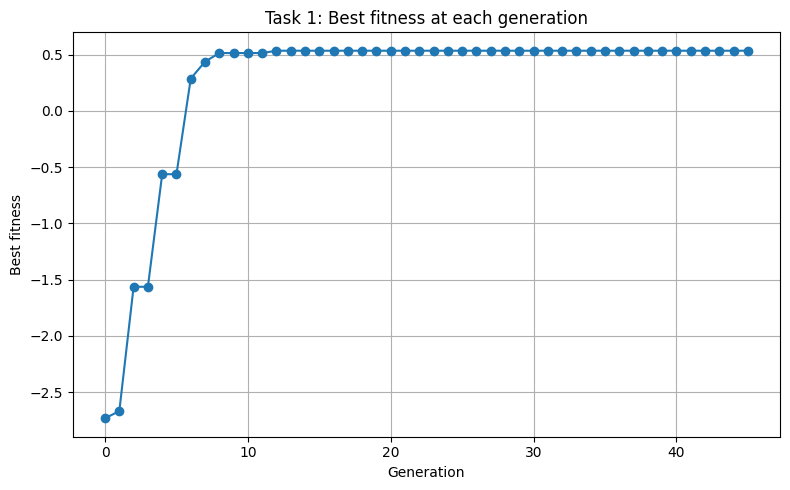

In [9]:
generations = logbook.select("gen")
best_fitness_per_generation = logbook.select("max")

plt.figure(figsize=(8, 5))
plt.plot(generations, best_fitness_per_generation, marker="o")
plt.xlabel("Generation")
plt.ylabel("Best fitness")
plt.title("Task 1: Best fitness at each generation")
plt.grid(True)
plt.tight_layout()
plt.savefig("task1_best_fitness.png", dpi=200)
plt.show()

In [12]:
N_RUNS = 10  

def run_variant(cx_op, mut_op, sel_op, n_runs=N_RUNS, seed_offset=0):

    best_fitnesses = []
    abf_curves = []

    start = time.time()

    for run in range(n_runs):
        random.seed(seed_offset + run)
        np.random.seed(seed_offset + run)

        tb = base.Toolbox()
        tb.register("attr_place", random.randint, LOWER_BOUND, UPPER_BOUND)
        tb.register(
            "individual", tools.initRepeat,
            creator.Individual_Task1, tb.attr_place, n=INDIVIDUAL_LENGTH,
        )
        tb.register("population", tools.initRepeat, list, tb.individual)
        tb.register("evaluate", support.fitness)
        tb.register("mate", cx_op)
        tb.register("mutate", mut_op, indpb=PER_GENE_MUTATION_PROBABILITY)
        if sel_op == tools.selTournament:
            tb.register("select", sel_op, tournsize=TOURNAMENT_SIZE)
        else:
            tb.register("select", sel_op)

        pop = tb.population(n=POPULATION_SIZE)
        hof = tools.HallOfFame(1)

        stats = tools.Statistics(lambda ind: ind.fitness.values[0])
        stats.register("max", np.max)

        pop, log = algorithms.eaSimple(
            pop, tb,
            cxpb=CROSSOVER_PROBABILITY,
            mutpb=MUTATION_PROBABILITY,
            ngen=N_GENERATIONS,
            stats=stats,
            halloffame=hof,
            verbose=False,
        )

        best_fitnesses.append(hof[0].fitness.values[0])
        abf_curves.append(log.select("max"))

    total_time = time.time() - start
    return best_fitnesses, abf_curves, total_time

In [13]:

variants = [
    # (label,               cx_op,            mut_op,                    sel_op)
    ("cxTwoPoint\nmutFlipBit\nselTournament",
        tools.cxTwoPoint,  tools.mutFlipBit,         tools.selTournament),
    ("cxTwoPoint\nmutFlipBit\nselRoulette",
        tools.cxTwoPoint,  tools.mutFlipBit,         tools.selRoulette),
    ("cxTwoPoint\nmutShuffleIndexes\nselTournament",
        tools.cxTwoPoint,  tools.mutShuffleIndexes,  tools.selTournament),
    ("cxTwoPoint\nmutShuffleIndexes\nselRoulette",
        tools.cxTwoPoint,  tools.mutShuffleIndexes,  tools.selRoulette),
    ("cxOrdered\nmutFlipBit\nselTournament",
        tools.cxOrdered,   tools.mutFlipBit,         tools.selTournament),
    ("cxOrdered\nmutFlipBit\nselRoulette",
        tools.cxOrdered,   tools.mutFlipBit,         tools.selRoulette),
    ("cxOrdered\nmutShuffleIndexes\nselTournament",
        tools.cxOrdered,   tools.mutShuffleIndexes,  tools.selTournament),
    ("cxOrdered\nmutShuffleIndexes\nselRoulette",
        tools.cxOrdered,   tools.mutShuffleIndexes,  tools.selRoulette),
]

results = {}  

for label, cx, mut, sel in variants:
    print(f"Running: {label.replace(chr(10), ' | ')} ...", end=" ", flush=True)
    bf, curves, t = run_variant(cx, mut, sel)
    results[label] = (bf, curves, t)
    abf = np.mean([c[-1] for c in curves])   
    print(f"ABF={abf:.4f}  time={t:.1f}s")

Running: cxTwoPoint | mutFlipBit | selTournament ... ABF=0.5935  time=1924.4s
Running: cxTwoPoint | mutFlipBit | selRoulette ... ABF=0.3668  time=2716.3s
Running: cxTwoPoint | mutShuffleIndexes | selTournament ... ABF=0.6535  time=1898.9s
Running: cxTwoPoint | mutShuffleIndexes | selRoulette ... ABF=0.3402  time=1395.2s
Running: cxOrdered | mutFlipBit | selTournament ... ABF=-0.3781  time=987.9s
Running: cxOrdered | mutFlipBit | selRoulette ... ABF=0.1695  time=1469.7s
Running: cxOrdered | mutShuffleIndexes | selTournament ... ABF=-0.1788  time=1107.9s
Running: cxOrdered | mutShuffleIndexes | selRoulette ... ABF=0.3455  time=1406.7s


In [14]:
print(f"\n{'Crossover':<18} {'Mutation':<22} {'Selection':<16} {'ABF':>8} {'Time(s)':>10}")
print("-" * 78)

for label, cx, mut, sel in variants:
    bf, curves, t = results[label]
    abf = np.mean([c[-1] for c in curves])
    cx_name, mut_name, sel_name = label.split("\n")
    print(f"{cx_name:<18} {mut_name:<22} {sel_name:<16} {abf:>8.4f} {t:>10.1f}")


Crossover          Mutation               Selection             ABF    Time(s)
------------------------------------------------------------------------------
cxTwoPoint         mutFlipBit             selTournament      0.5935     1924.4
cxTwoPoint         mutFlipBit             selRoulette        0.3668     2716.3
cxTwoPoint         mutShuffleIndexes      selTournament      0.6535     1898.9
cxTwoPoint         mutShuffleIndexes      selRoulette        0.3402     1395.2
cxOrdered          mutFlipBit             selTournament     -0.3781      987.9
cxOrdered          mutFlipBit             selRoulette        0.1695     1469.7
cxOrdered          mutShuffleIndexes      selTournament     -0.1788     1107.9
cxOrdered          mutShuffleIndexes      selRoulette        0.3455     1406.7


C:\Users\20210295\AppData\Local\Temp\ipykernel_33336\2804229213.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_best, labels=labels_short, patch_artist=True)


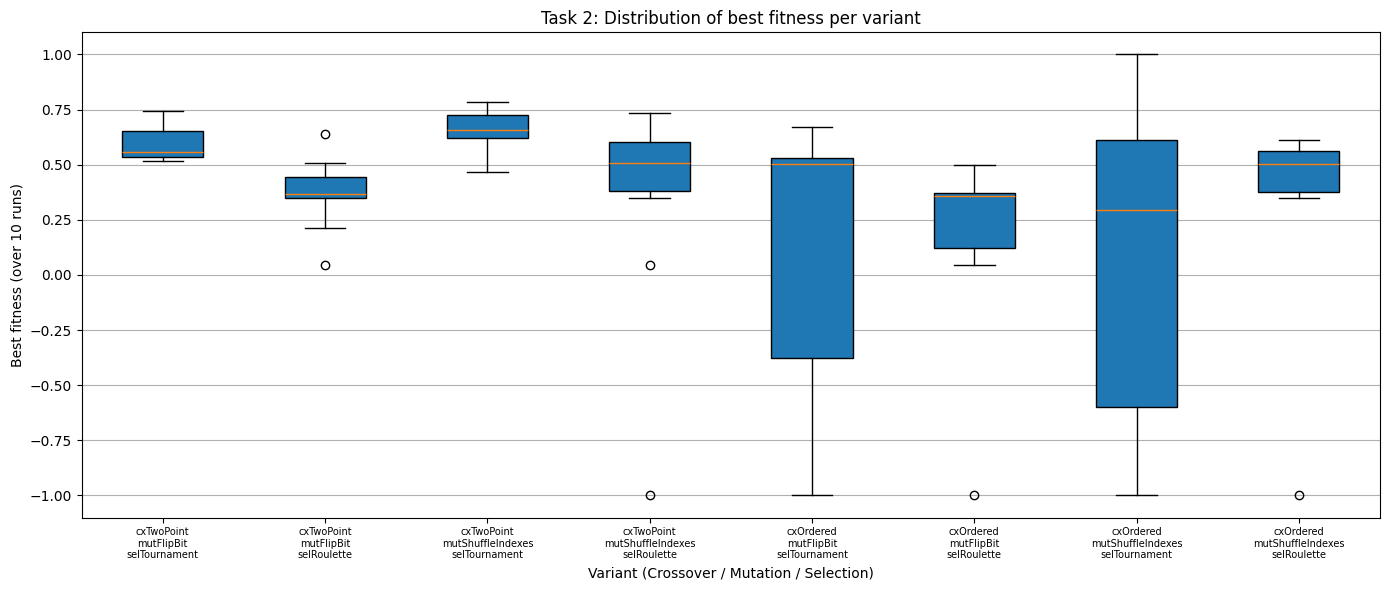

In [15]:
labels_short = [lbl.replace("\n", "\n") for lbl, *_ in variants]
all_best = [results[lbl][0] for lbl, *_ in variants]

fig, ax = plt.subplots(figsize=(14, 6))
ax.boxplot(all_best, labels=labels_short, patch_artist=True)
ax.set_xlabel("Variant (Crossover / Mutation / Selection)")
ax.set_ylabel("Best fitness (over 10 runs)")
ax.set_title("Task 2: Distribution of best fitness per variant")
ax.tick_params(axis="x", labelsize=7)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("task2_boxplots.png", dpi=200)
plt.show()

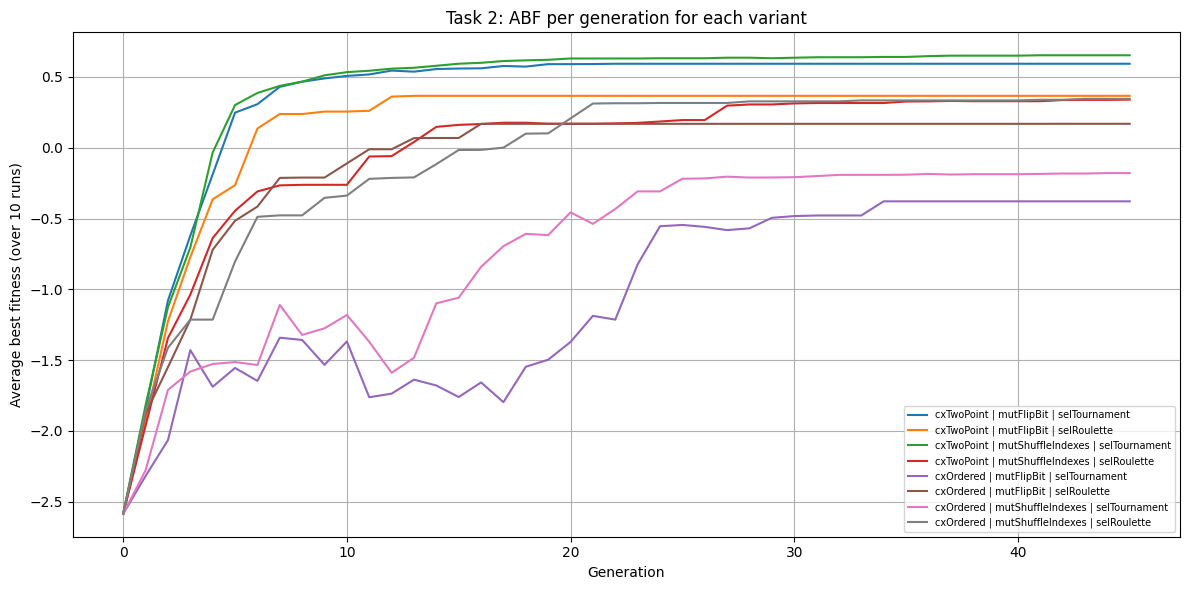

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

for label, *_ in variants:
    _, curves, _ = results[label]
    mean_curve = np.mean(curves, axis=0)
    ax.plot(range(N_GENERATIONS + 1), mean_curve, label=label.replace("\n", " | "))

ax.set_xlabel("Generation")
ax.set_ylabel("Average best fitness (over 10 runs)")
ax.set_title("Task 2: ABF per generation for each variant")
ax.legend(fontsize=7, loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("task2_abf_lines.png", dpi=200)
plt.show()